# Hoja de trabajo 7: modelos de regresión logística
Integrantes: 
- Francis Aguilar #22243
- Angela Garcia #22869  

Enlace de repositorio: https://github.com/angelargd8/HTD7-MDD 

In [128]:
import numpy
import pandas as pg
import matplotlib.pyplot as plt

#cargar los datos
import pandas as pd 
df_train = pd.read_csv("train.csv")

### Variables que no se tomarán en cuenta por falta de datos
No se tomarán en cuenta las siguiente variables porque tienen demasiados datos faltantes, según las respuestas anteriores, estar variables no nos serán de utilidad.   
Demasiados datos faltantes, irrelevante para el análisis   
- **Alley** 91 non-null / 1460 registros 
- **MasVnrType** 588 non-null / 1460
- **FireplaceQu** 770 non-null / 1460
- **PoolQC** 7 non-null / 1460
- **Fence** 281 non-null / 1460    
- **MiscFeature** 54 non-null / 1460

In [129]:
print(df_train.shape)
# Eliminar las columnas 
columnas_a_eliminar = ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']  # Reemplaza con los nombres de las columnas que deseas eliminar
df_train = df_train.drop(columns=columnas_a_eliminar)
print(df_train.shape)
print("Se eliminaron un total de 6 columnas")

(1460, 81)
(1460, 75)
Se eliminaron un total de 6 columnas


### 1. Cree una variable dicotómica por cada una de las categorías de la variable respuesta categórica que creó en hojas anteriores. Debería tener 3 variables dicotómicas (valores 0 y 1) una que diga si la vivienda es cara o no, media o no, económica o no.

In [130]:
#calcular percentiles 33 y 66 %%
import seaborn as sns

df_train = pd.read_csv("train.csv")
df_numerico = df_train.select_dtypes(include=['number'])
df_numerico.dropna(inplace=True)

low = df_train['SalePrice'].quantile(0.33)

medium = df_train['SalePrice'].quantile(0.66)

high = df_train['SalePrice'].max()

df_train['SalePrice_Class'] = pd.cut(df_train['SalePrice'], bins=[0, low, medium, high], labels=['Economic', 'Intermediate', 'High'])

print(df_train['SalePrice_Class'].value_counts())


SalePrice_Class
High            497
Economic        483
Intermediate    480
Name: count, dtype: int64


In [131]:
#creacion de 3 variables dicotomicas, con valores de 0 y 1 que diga si la vivienda es cara o no, media o no, economica o no 
dummy_economic = df_train['Economic'] = (df_train['SalePrice_Class'] == 'Economic').astype(int)
dummy_intermediate = df_train['Intermediate'] = (df_train['SalePrice_Class'] == 'Intermediate').astype(int)
dummy_high =df_train['High'] = (df_train['SalePrice_Class'] == 'High').astype(int)

#unir las variables dummy con el dataframe original
df_train = pd.concat([df_train, dummy_economic, dummy_intermediate, dummy_high], axis=1)
#verificamos que se hayan unido las variables
print(df_train[['SalePrice', 'Economic', 'Intermediate', 'High']].head(10))


   SalePrice  Economic  Intermediate  High
0     208500         0             0     1
1     181500         0             1     0
2     223500         0             0     1
3     140000         0             1     0
4     250000         0             0     1
5     143000         0             1     0
6     307000         0             0     1
7     200000         0             0     1
8     129900         1             0     0
9     118000         1             0     0


### 2. Use los mismos conjuntos de entrenamiento y prueba que utilizó en las hojas anteriores.

In [132]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

df_train = df_train.loc[df_numerico.index]
variables_numericas = df_numerico.select_dtypes(include=[np.number]).columns.tolist()
print("Variables numéricas:", variables_numericas)

X = df_numerico[variables_numericas].drop(columns=['SalePrice', 'SalePrice_Class', ''], errors='ignore')
y = df_train['High']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Shape of X_train:", X_train.shape)

Variables numéricas: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Shape of X: (1121, 37)
Shape of y: (1121,)
Shape of X_train: (896, 37)


### 4. Elabore un modelo de regresión logística para conocer si una vivienda es cara o no, utilizando el conjunto de entrenamiento y explique los resultados a los que llega. El experimento debe ser reproducible por lo que debe fijar que los conjuntos de entrenamiento y prueba sean los mismos siempre que se ejecute el código. Use validación cruzada. 

In [133]:
logReg = LogisticRegression(solver='liblinear')
logReg.fit(X_train,y_train)
y_pred = logReg.predict(X_test)
y_proba = logReg.predict_proba(X_test)[:,1] # vector de probabilidades
cm = confusion_matrix(y_test,y_pred)

In [134]:
#cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(logReg, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())

Cross-validation scores: [0.95555556 0.88826816 0.88826816 0.86592179 0.91620112]
Mean cross-validation score: 0.9028429546865301


c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Los resultados del cross validation, lo que nos indican los puntajes o el ¨scores¨ son la precision del modelo, de cada subconjunto. Y se observa que los puntajes estan dentro del rango de 0.86 a 0.95, hay cierta variavilidad, pero tiene buen rendimiento.
El promedio due de 0.90, lo que nos indica que el modelo precide bien el 90% de las veces. 

In [135]:
y_proba

array([1.34867797e-02, 5.41951838e-02, 3.34899283e-04, 1.05154096e-02,
       1.63924955e-01, 9.72752519e-01, 1.49893092e-02, 2.00918620e-02,
       8.05229718e-01, 2.08959102e-03, 1.63954752e-01, 9.99500283e-01,
       8.76850596e-01, 1.34904129e-02, 3.62351010e-03, 3.93111443e-03,
       5.03306644e-03, 5.94058192e-02, 5.69176085e-01, 2.21258383e-01,
       7.64429822e-01, 2.06545471e-03, 3.47652509e-04, 8.20276519e-01,
       3.92454420e-02, 4.10274864e-04, 9.99999911e-01, 7.98971614e-04,
       2.48231087e-02, 3.74957623e-02, 6.95837182e-01, 8.26956278e-01,
       2.55751218e-01, 9.90436065e-01, 9.98541332e-01, 3.03562754e-01,
       4.21221347e-01, 4.44119387e-02, 4.22490161e-01, 1.03906935e-04,
       6.79009178e-02, 9.34280534e-01, 3.32646533e-03, 1.40185687e-03,
       9.97655360e-01, 8.97069417e-01, 2.85282201e-03, 2.63338888e-01,
       1.64408928e-02, 9.51181537e-02, 3.14288287e-01, 9.72132373e-01,
       8.04699019e-02, 2.49761061e-01, 5.58067256e-01, 8.84531079e-01,
      

In [136]:
y_test

1297    0
132     0
300     0
1307    0
778     0
1330    1
576     0
1434    0
174     0
1225    0
1080    0
112     1
732     1
625     0
873     0
373     0
563     0
55      0
388     1
1052    0
143     1
150     0
430     0
69      1
1398    0
553     0
691     1
1393    0
962     0
213     0
1402    1
471     1
695     0
554     1
423     1
109     1
1051    1
1103    0
949     1
589     0
689     1
885     1
1452    0
719     0
1175    1
1303    1
1295    0
1023    1
123     0
662     0
849     0
688     1
599     0
355     0
62      1
930     1
491     0
86      0
315     0
1001    0
708     0
263     0
969     0
232     0
700     1
574     0
1416    0
1149    0
955     0
769     1
468     1
1042    1
1294    0
378     1
37      0
1418    0
429     0
981     1
1053    0
398     0
549     1
1145    0
943     0
211     0
699     1
400     1
1382    0
1401    1
631     1
805     1
808     0
578     0
320     1
11      1
827     0
382     1
829     0
256     1
424     0
1044    1


### 4. Analice el modelo. Determine si hay multicolinealidad en las variables, y cuáles son las que aportan al modelo, por su valor de significación. Haga un análisis de correlación de las variables del modelo y especifique si el modelo se adapta bien a los datos.

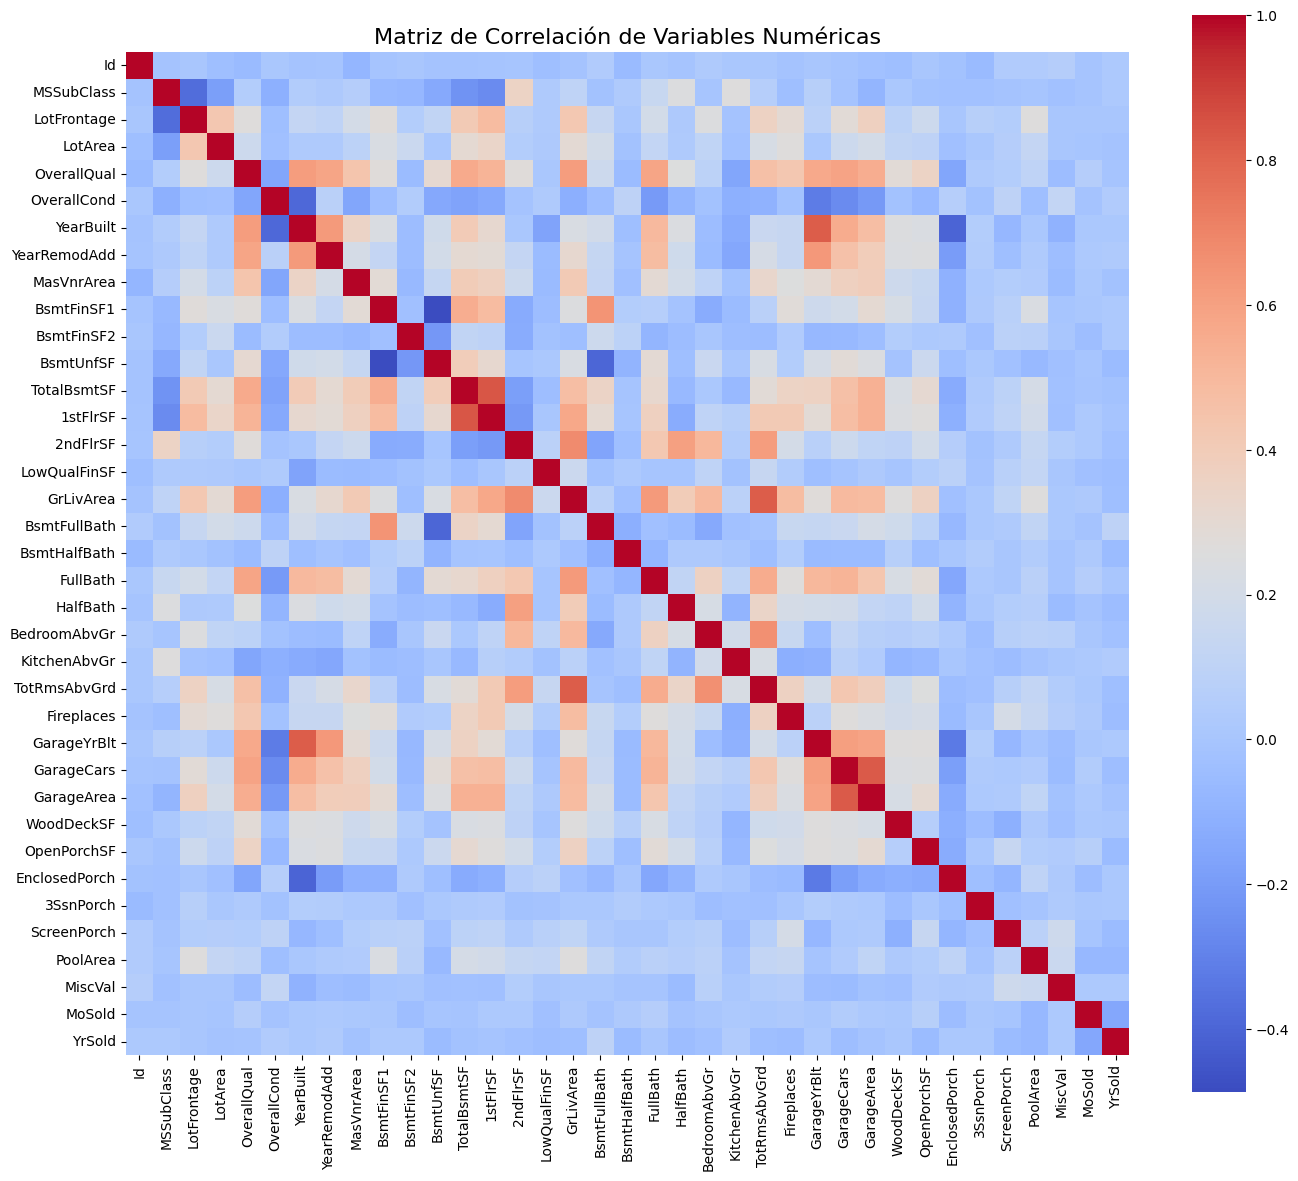

In [137]:
#determinar si hay multicolinealidad entre las variables
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
correlation_matrix = X_train.corr()

# Graficar mapa de calor
plt.figure(figsize=(14, 12))  # Ajusta el tamaño según la cantidad de variables
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matriz de Correlación de Variables Numéricas", fontsize=16)
plt.tight_layout()
plt.show()


In [138]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# df para mostrar los VIFs
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# resultados
pd.set_option("display.max_rows", None) 
print(vif_df.sort_values(by="VIF", ascending=False))

         Variable        VIF
16      GrLivArea        inf
9      BsmtFinSF1        inf
10     BsmtFinSF2        inf
11      BsmtUnfSF        inf
12    TotalBsmtSF        inf
14       2ndFlrSF        inf
15   LowQualFinSF        inf
13       1stFlrSF        inf
25    GarageYrBlt 26863.6473
36         YrSold 25291.0788
6       YearBuilt 24671.1345
7    YearRemodAdd 24526.0400
23   TotRmsAbvGrd    83.7546
4     OverallQual    73.3371
5     OverallCond    49.6622
22   KitchenAbvGr    42.0755
26     GarageCars    39.8594
27     GarageArea    35.2262
21   BedroomAbvGr    33.8167
19       FullBath    28.7673
2     LotFrontage    17.3133
35         MoSold     6.8409
1      MSSubClass     4.8250
0              Id     4.1239
17   BsmtFullBath     3.6581
20       HalfBath     3.5948
3         LotArea     3.4586
24     Fireplaces     3.0282
29    OpenPorchSF     1.9660
28     WoodDeckSF     1.9458
8      MasVnrArea     1.9448
30  EnclosedPorch     1.4867
32    ScreenPorch     1.2400
18   BsmtHalfB

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Se realizo una matriz de correlación y VIF para ver la multicolinealidad de los datos. 
Lo primero que se puede ver en la matriz de correlación, es que hay correlaciones fuertes, porque se ven varios cuadros rojos que están afuera de la diagonal. Como en GarageArea y GarageCars. Mientras, que en el VIF, hay muchos resultados con INF, que quiere decir que esas columnas deben de ser eliminadas o transformadas, porque hay multicolinealidad. 

### 5. Utilice el modelo con el conjunto de prueba y determine la eficiencia del algoritmo para clasificar. 

In [139]:
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión para clasificar el precio de las casas\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ',precision)
print('Recall: ',recall)
print('F1: ',f1)


Matriz de confusión para clasificar el precio de las casas
 [[128   8]
 [ 15  74]]
Accuracy:  0.8977777777777778
Precision:  0.8977777777777778
Recall:  0.8977777777777778
F1:  0.8977777777777778


En los resultados del modelo al clasificar el precio de las casas, tuvo buenos resultados. Con un accuracy del 89% en donde las predicciones fueron correctas. Mientras, tuvo precisión de 89% en donde las predicciones fueron correctas y 11% de las predicciones fueron incorrectas. En recall, tuvo el mismo resultado al igual que F1.

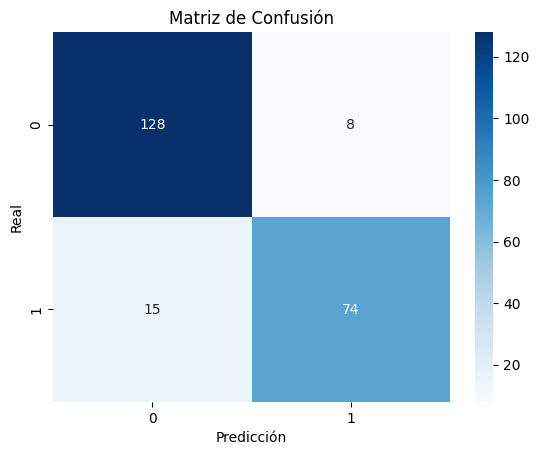

In [140]:
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', )
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

Lo que se puede observar en los resultados es que, 128 viviendas fueron correctamente clasificadas como no caras y el modelo se confundio solamente con 8. Mientras que, al clasificarlas como caras tuvo mas problemas, porque 74 fueron clasificadas correctamente, mientras que 15 no.


Etiquetas únicas en y_test: [0 1]
1297    0
132     0
300     0
1307    0
778     0
1330    1
576     0
1434    0
174     0
1225    0
Name: High, dtype: int64
Etiquetas únicas en custom_preds: [0 1]


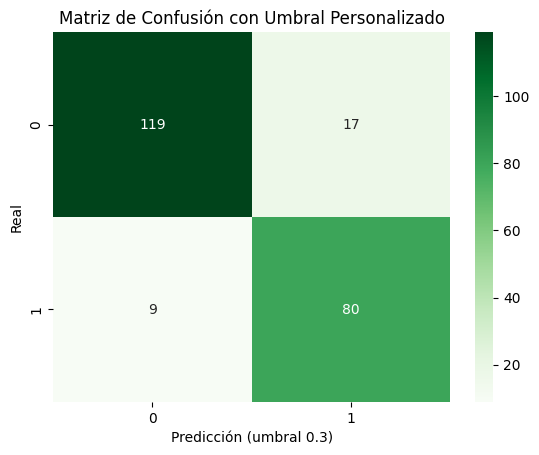

In [148]:
#uso del umbral 
custom_threshold = 0.3
custom_preds = (y_proba >= custom_threshold).astype(int)

# Verificar las etiquetas únicas en y_test y custom_preds
print("Etiquetas únicas en y_test:", np.unique(y_test))

print(y_test.head(10))

print("Etiquetas únicas en custom_preds:", np.unique(custom_preds))

# Nueva matriz de confusión
cm_custom = confusion_matrix(y_test, custom_preds)
sns.heatmap(cm_custom, annot=True, cmap='Greens', fmt='d')
plt.xlabel("Predicción (umbral 0.3)")
plt.ylabel("Real")
plt.title("Matriz de Confusión con Umbral Personalizado")
plt.show()


Los resultados del umbral, lo que me dice es que con el umbral de 0.3 es que tuvo 119 verdaderos positivos, prediciendo bien las no caras, 17 Falsos positivos, 9 Falsos negativos y 80 verdaderos positivos, que predijo bien las caras.

Con el umbral de 0.3, se aumento el recall, detectando más viviendas caras, pero se bajo la precision, diciendo que algunas no son caras cuando si lo son, entonces aumentarion los falsos positivos. 

Auroc y recall

Área bajo la curva ROC (AUROC): 0.9662921348314607


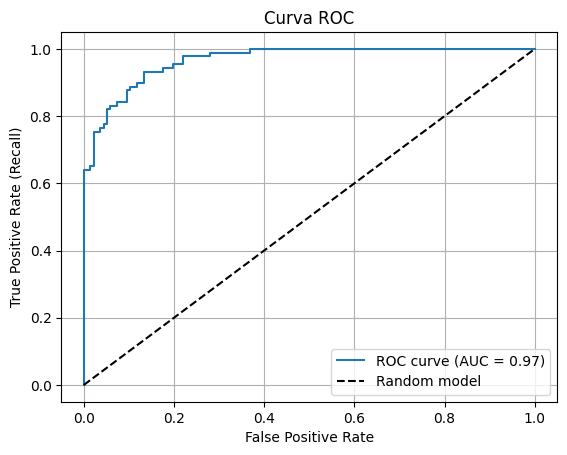

In [149]:
# Cálculo del AUROC
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

auroc = roc_auc_score(y_test, y_proba)
print("Área bajo la curva ROC (AUROC):", auroc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auroc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

El auroc es de 96.62%, por lo cual es un buen modelo de clasificación. Al observar la gráfica podemos ver que el modelo clasifica con precision las viviendas caras y las no caras.

In [143]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_df = pd.DataFrame({
    "Threshold": thresholds,
    "TPR (Recall)": tpr,
    "FPR": fpr
})

# Opcional: ajustar el formato para que sea más fácil de leer
pd.set_option('display.float_format', '{:.4f}'.format)

# Mostrar la tabla
print(roc_df)

    Threshold  TPR (Recall)    FPR
0         inf        0.0000 0.0000
1      1.0000        0.0112 0.0000
2      0.8096        0.6404 0.0000
3      0.7916        0.6404 0.0147
4      0.7868        0.6517 0.0147
5      0.7860        0.6517 0.0221
6      0.6958        0.7528 0.0221
7      0.6475        0.7528 0.0368
8      0.6453        0.7640 0.0368
9      0.6411        0.7640 0.0441
10     0.6093        0.7753 0.0441
11     0.6066        0.7753 0.0515
12     0.5502        0.8202 0.0515
13     0.5446        0.8202 0.0588
14     0.5188        0.8315 0.0588
15     0.4712        0.8315 0.0735
16     0.4535        0.8427 0.0735
17     0.4288        0.8427 0.0956
18     0.4212        0.8764 0.0956
19     0.4065        0.8764 0.1029
20     0.3283        0.8876 0.1029
21     0.3143        0.8876 0.1176
22     0.3036        0.8989 0.1176
23     0.2709        0.8989 0.1324
24     0.2586        0.9326 0.1324
25     0.2192        0.9326 0.1765
26     0.2097        0.9438 0.1765
27     0.1639       

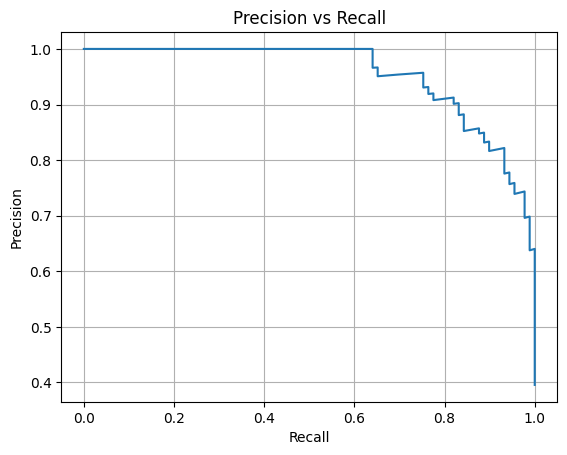

In [147]:
# RECALL
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(recall, precision, label="Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall")
plt.grid(True)
plt.show()


Lo que podemos ver en el resultado de precision vs recall, es que al inicio el modelo casi no se equivoca, solo predice cara cuando esta seguro. Mientras va aumentando el recall toma más casos positicvos, pero la precision baja, que es cuando hace falsos positivos. En el final, la precision es baja, alli toma todos los positivos, pero casifica mal muchas viviendas que no son caras como caras. 